# Обнаружение мошенничества в банковских транзакциях - GRU (Тюнинг)

## Часть 1: Настройка окружения

Инициализация зависимостей, логирования и параметров визуализации.

In [1]:
import logging
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, roc_curve,
    f1_score, fbeta_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    average_precision_score
)

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

# Setup
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# PyTorch settings
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
torch.manual_seed(42)
np.random.seed(42)

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
logger.info(f"Окружение инициализировано. Устройство: {device}")

/Users/berdov/project3/fraud_detection/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-05 23:42:00,470 - INFO - Окружение инициализировано. Устройство: mps


## Часть 2: Загрузка и подготовка данных

Загрузка транзакций и организация их в последовательности по клиентам.

In [2]:
df_train = pd.read_csv("train.csv")
df_val = pd.read_csv("val.csv")
df_test = pd.read_csv("test.csv")

logger.info(f"Тренировочный набор: {df_train.shape[0]:,} транзакций x {df_train.shape[1]} признаков")
logger.info(f"Валидационный набор: {df_val.shape[0]:,} транзакций x {df_val.shape[1]} признаков")
logger.info(f"Тестовый набор: {df_test.shape[0]:,} транзакций x {df_test.shape[1]} признаков")
logger.info(f"Доля мошенничества (тренировка): {df_train['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (валидация): {df_val['FraudResult'].mean():.2%}")
logger.info(f"Доля мошенничества (тест): {df_test['FraudResult'].mean():.2%}")

print("\nСводка данных:")
print(f"  Уникальных клиентов (тренировка): {df_train['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (валидация): {df_val['CustomerId'].nunique():,}")
print(f"  Уникальных клиентов (тест): {df_test['CustomerId'].nunique():,}")
print(f"  Средний размер последовательности: {len(df_train) / df_train['CustomerId'].nunique():.1f} транзакций")

2026-04-05 23:42:00,782 - INFO - Тренировочный набор: 54,459 транзакций x 10 признаков
2026-04-05 23:42:00,783 - INFO - Валидационный набор: 21,537 транзакций x 10 признаков
2026-04-05 23:42:00,783 - INFO - Тестовый набор: 19,666 транзакций x 10 признаков
2026-04-05 23:42:00,787 - INFO - Доля мошенничества (тренировка): 0.17%
2026-04-05 23:42:00,788 - INFO - Доля мошенничества (валидация): 0.21%
2026-04-05 23:42:00,789 - INFO - Доля мошенничества (тест): 0.29%



Сводка данных:
  Уникальных клиентов (тренировка): 2,245
  Уникальных клиентов (валидация): 748
  Уникальных клиентов (тест): 749
  Средний размер последовательности: 24.3 транзакций


## Часть 3: Инженерия признаков и подготовка последовательностей

Извлечение признаков и организация данных в последовательности для обработки GRU.

In [3]:
import random

def reset_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [4]:
def prepare_transaction_features(df):
    """
    Подготовка признаков для каждой транзакции.
    """
    df = df.copy()
    
    id_columns = ["ProviderId", "ProductId", "ChannelId"]
    
    for col in id_columns:
        if col in df.columns:
            df[col] = df[col].astype(str).str.extract(r"(\d+)$", expand=False).astype("Int64")
    
    if "TransactionStartTime" in df.columns:
        df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"], utc=True)
        df["tx_hour"] = df["TransactionStartTime"].dt.hour
        df["tx_dayofweek"] = df["TransactionStartTime"].dt.dayofweek
        df["tx_month"] = df["TransactionStartTime"].dt.month
        df["tx_is_weekend"] = (df["TransactionStartTime"].dt.dayofweek >= 5).astype(int)
        df = df.drop(columns=["TransactionStartTime"])
    
    return df


logger.info("Подготовка признаков для транзакций...")
train_features = prepare_transaction_features(df_train)
val_features = prepare_transaction_features(df_val)
test_features = prepare_transaction_features(df_test)

# Единое кодирование ProductCategory по train
if "ProductCategory" in train_features.columns:
    train_features["ProductCategory"] = train_features["ProductCategory"].fillna("__MISSING__").astype(str)
    val_features["ProductCategory"] = val_features["ProductCategory"].fillna("__MISSING__").astype(str)
    test_features["ProductCategory"] = test_features["ProductCategory"].fillna("__MISSING__").astype(str)

    product_category_mapping = {
        category: idx
        for idx, category in enumerate(train_features["ProductCategory"].unique())
    }

    train_features["ProductCategory"] = (
        train_features["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

    val_features["ProductCategory"] = (
        val_features["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

    test_features["ProductCategory"] = (
        test_features["ProductCategory"]
        .map(product_category_mapping)
        .fillna(-1)
        .astype(int)
    )

# Выравнивание колонок во всех датасетах
common_cols = list(set(train_features.columns) & set(val_features.columns) & set(test_features.columns))
common_cols = sorted(common_cols)

train_features = train_features[common_cols]
val_features = val_features[common_cols]
test_features = test_features[common_cols]

logger.info(f"Признаки подготовлены - {train_features.shape[1]} признаков")
logger.info(f"Выровненные колонки: {common_cols}")

2026-04-05 23:42:00,848 - INFO - Подготовка признаков для транзакций...
2026-04-05 23:42:01,238 - INFO - Признаки подготовлены - 13 признаков
2026-04-05 23:42:01,239 - INFO - Выровненные колонки: ['Amount', 'ChannelId', 'CustomerId', 'FraudResult', 'PricingStrategy', 'ProductCategory', 'ProductId', 'ProviderId', 'TransactionId', 'tx_dayofweek', 'tx_hour', 'tx_is_weekend', 'tx_month']


### Создание последовательностей для каждого клиента

In [5]:
def create_client_sequences(df, max_seq_len=100):
    """
    Организация транзакций в последовательности по клиентам.
    
    Args:
        df: DataFrame с транзакциями
        max_seq_len: максимальная длина последовательности
        
    Returns:
        sequences: список массивов признаков
        labels: список меток (fraud/not fraud)
        client_ids: список ID клиентов
    """
    # Определение признаков (исключаем ID и целевую переменную)
    TARGET_COL = "FraudResult"
    CLIENT_ID_COL = "CustomerId"
    
    exclude_cols = {
        TARGET_COL, "TransactionId", "BatchId", "SubscriptionId",
        "CustomerId", "quantile"
    }
    
    feature_cols = [c for c in df.columns if c not in exclude_cols]
    
    # Группировка по клиентам
    sequences = []
    labels = []
    client_ids = []
    
    for account_id, group in df.groupby(CLIENT_ID_COL, sort=False):
        # Извлечение признаков для последовательности
        seq = group[feature_cols].values.astype(np.float32)
        
        # Обрезка или дополнение
        if len(seq) > max_seq_len:
            seq = seq[-max_seq_len:]  # берем последние транзакции
        
        # Padding нулями в начало
        if len(seq) < max_seq_len:
            padding = np.zeros((max_seq_len - len(seq), seq.shape[1]), dtype=np.float32)
            seq = np.vstack([padding, seq])
        
        # Целевая переменная: был ли хотя бы один fraud у клиента
        label = int(group[TARGET_COL].max())
        
        sequences.append(seq)
        labels.append(label)
        client_ids.append(account_id)
    
    return np.array(sequences), np.array(labels), np.array(client_ids), feature_cols


logger.info("Создание последовательностей клиентов...")
train_sequences, train_labels, train_clients, feature_cols = create_client_sequences(train_features)
val_sequences, val_labels, val_clients, _ = create_client_sequences(val_features)
test_sequences, test_labels, test_clients, _ = create_client_sequences(test_features)

logger.info(f"Тренировочные последовательности: {train_sequences.shape}")
logger.info(f"Валидационные последовательности: {val_sequences.shape}")
logger.info(f"Тестовые последовательности: {test_sequences.shape}")
logger.info(f"Распределение меток (тренировка): {np.bincount(train_labels)}")
logger.info(f"Распределение меток (валидация): {np.bincount(val_labels)}")
logger.info(f"Распределение меток (тест): {np.bincount(test_labels)}")
logger.info(f"Всего признаков в последовательности: {len(feature_cols)}")

print(f"\nРазмер последовательностей:")
print(f"  Максимальная длина: 100 транзакций")
print(f"  Размер признаков: {train_sequences.shape[2]}")
print(f"  Клиентов (тренировка): {len(train_sequences)}")
print(f"  Клиентов (валидация): {len(val_sequences)}")
print(f"  Клиентов (тест): {len(test_sequences)}")

2026-04-05 23:42:01,264 - INFO - Создание последовательностей клиентов...
2026-04-05 23:42:02,950 - INFO - Тренировочные последовательности: (2245, 100, 10)
2026-04-05 23:42:02,952 - INFO - Валидационные последовательности: (748, 100, 10)
2026-04-05 23:42:02,953 - INFO - Тестовые последовательности: (749, 100, 10)
2026-04-05 23:42:02,954 - INFO - Распределение меток (тренировка): [2213   32]
2026-04-05 23:42:02,954 - INFO - Распределение меток (валидация): [735  13]
2026-04-05 23:42:02,955 - INFO - Распределение меток (тест): [740   9]
2026-04-05 23:42:02,955 - INFO - Всего признаков в последовательности: 10



Размер последовательностей:
  Максимальная длина: 100 транзакций
  Размер признаков: 10
  Клиентов (тренировка): 2245
  Клиентов (валидация): 748
  Клиентов (тест): 749


### Нормализация признаков

In [6]:
# Нормализация последовательностей
# Reshape для StandardScaler: (n_clients, seq_len, n_features) -> (n_clients*seq_len, n_features)
n_clients, seq_len, n_features = train_sequences.shape
training_reshaped = train_sequences.reshape(-1, n_features)

scaler = StandardScaler()
training_scaled_reshaped = scaler.fit_transform(training_reshaped)
training_sequences_scaled = training_scaled_reshaped.reshape(n_clients, seq_len, n_features)

# Применение того же scaler к валидации
val_reshaped = val_sequences.reshape(-1, n_features)
val_scaled_reshaped = scaler.transform(val_reshaped)
val_sequences_scaled = val_scaled_reshaped.reshape(val_sequences.shape[0], seq_len, n_features)

# Применение того же scaler к тесту
test_reshaped = test_sequences.reshape(-1, n_features)
test_scaled_reshaped = scaler.transform(test_reshaped)
test_sequences_scaled = test_scaled_reshaped.reshape(test_sequences.shape[0], seq_len, n_features)

logger.info("Признаки нормализованы")
print(f"Нормализация - Статистика тренировки:")
print(f"  Mean: {training_sequences_scaled.reshape(-1, n_features).mean(axis=0)[:5]}...")
print(f"  Std:  {training_sequences_scaled.reshape(-1, n_features).std(axis=0)[:5]}...")

2026-04-05 23:42:03,046 - INFO - Признаки нормализованы


Нормализация - Статистика тренировки:
  Mean: [ 1.8011113e-05 -1.5995996e-04  2.7012502e-05  1.8363736e-04
  2.7989814e-04]...
  Std:  [0.9996074  0.99843687 1.0012281  0.99954414 1.0011429 ]...


### Преобразование в PyTorch tensors

In [7]:
# Преобразование в PyTorch
X_train_tensor = torch.FloatTensor(training_sequences_scaled)
y_train_tensor = torch.LongTensor(train_labels)

X_val_tensor = torch.FloatTensor(val_sequences_scaled)
y_val_tensor = torch.LongTensor(val_labels)

X_test_tensor = torch.FloatTensor(test_sequences_scaled)
y_test_tensor = torch.LongTensor(test_labels)

logger.info(f"Тренировочные тензоры: {X_train_tensor.shape}")
logger.info(f"Валидационные тензоры: {X_val_tensor.shape}")
logger.info(f"Тестовые тензоры: {X_test_tensor.shape}")

2026-04-05 23:42:03,087 - INFO - Тренировочные тензоры: torch.Size([2245, 100, 10])
2026-04-05 23:42:03,089 - INFO - Валидационные тензоры: torch.Size([748, 100, 10])
2026-04-05 23:42:03,090 - INFO - Тестовые тензоры: torch.Size([749, 100, 10])


## Часть 4: Архитектура модели GRU для последовательностей

In [8]:
class GRUClassifier(nn.Module):
    """
    Улучшенный классификатор на основе GRU для последовательностей транзакций.
    """
    def __init__(
        self,
        input_dim,
        hidden_dim=64,
        num_layers=2,
        num_classes=2,
        dropout=0.3,
        bidirectional=True
    ):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1

        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.gru = nn.GRU(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional
        )

        gru_out_dim = hidden_dim * self.num_directions

        self.layer_norm = nn.LayerNorm(gru_out_dim)

        self.attention = nn.Sequential(
            nn.Linear(gru_out_dim, gru_out_dim // 2),
            nn.Tanh(),
            nn.Linear(gru_out_dim // 2, 1)
        )

        self.dropout = nn.Dropout(dropout)

        combined_dim = gru_out_dim * 4

        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = self.input_proj(x)

        gru_out, h_n = self.gru(x)
        gru_out = self.layer_norm(gru_out)

        if self.bidirectional:
            last_forward = h_n[-2]
            last_backward = h_n[-1]
            last_hidden = torch.cat([last_forward, last_backward], dim=1)
        else:
            last_hidden = h_n[-1]

        attn_scores = self.attention(gru_out)
        attn_weights = torch.softmax(attn_scores, dim=1)
        attn_pooled = torch.sum(gru_out * attn_weights, dim=1)

        mean_pooled = torch.mean(gru_out, dim=1)
        max_pooled, _ = torch.max(gru_out, dim=1)

        features = torch.cat(
            [last_hidden, attn_pooled, mean_pooled, max_pooled],
            dim=1
        )

        features = self.dropout(features)
        logits = self.classifier(features)
        return logits


# ==================== FOCAL LOSS ====================

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        log_probs = F.log_softmax(inputs, dim=1)
        probs = torch.exp(log_probs)

        targets = targets.view(-1, 1)

        log_pt = log_probs.gather(1, targets).squeeze(1)
        pt = probs.gather(1, targets).squeeze(1)

        if self.alpha is not None:
            at = self.alpha.gather(0, targets.squeeze(1))
            loss = -at * ((1 - pt) ** self.gamma) * log_pt
        else:
            loss = -((1 - pt) ** self.gamma) * log_pt

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

## Часть 5: Обучение модели

Обучение классификатора GRU с ранней остановкой и мониторингом валидации.

2026-04-05 23:42:03,157 - INFO - Начало расширенного подбора гиперпараметров с Optuna...
[I 2026-04-05 23:42:03,165] A new study created in memory with name: gru_fraud_detection_tuning
Best trial: 0. Best value: 0.238095:   2%|▏         | 1/50 [02:19<1:53:53, 139.46s/it]

[I 2026-04-05 23:44:22,627] Trial 0 finished with value: 0.23809523809523808 and parameters: {'hidden_dim': 64, 'num_layers': 4, 'dropout': 0.5, 'learning_rate': 0.00041282053438262235, 'weight_decay': 6.026889128682501e-07, 'optimizer_type': 'sgd', 'criterion_type': 'weighted_ce', 'scheduler_type': 'none', 'batch_size': 128, 'clip_grad': 1.0, 'fraud_weight': 8.698270224554964, 'momentum': 0.9162520499972521}. Best is trial 0 with value: 0.23809523809523808.


Best trial: 0. Best value: 0.238095:   4%|▍         | 2/50 [08:25<3:38:12, 272.76s/it]

[I 2026-04-05 23:50:28,698] Trial 1 finished with value: 0.06535947712418301 and parameters: {'hidden_dim': 32, 'num_layers': 2, 'dropout': 0.30000000000000004, 'learning_rate': 0.00017018418817029164, 'weight_decay': 0.000843101393208247, 'optimizer_type': 'sgd', 'criterion_type': 'weighted_ce', 'scheduler_type': 'cosine', 'batch_size': 16, 'clip_grad': 1.0, 'fraud_weight': 4.806879401429913, 'momentum': 0.8940836129211414}. Best is trial 0 with value: 0.23809523809523808.


Best trial: 2. Best value: 0.918367:   6%|▌         | 3/50 [10:43<2:45:32, 211.33s/it]

...

Best trial: 2. Best value: 0.918367:  98%|█████████▊| 49/50 [3:22:45<04:39, 279.67s/it]

[I 2026-04-06 03:04:48,563] Trial 48 pruned. 


Best trial: 2. Best value: 0.918367: 100%|██████████| 50/50 [3:23:13<00:00, 243.87s/it]
2026-04-06 03:05:16,572 - INFO - 
2026-04-06 03:05:16,584 - INFO - Подбор гиперпараметров завершен за 50 trials
2026-04-06 03:05:16,584 - INFO - Лучший F0.5 на валидации: 0.9184
2026-04-06 03:05:16,584 - INFO - 
Оптимальные гиперпараметры:
2026-04-06 03:05:16,585 - INFO -   batch_size           = 128
2026-04-06 03:05:16,585 - INFO -   clip_grad            = 1.000000
2026-04-06 03:05:16,585 - INFO -   criterion_type       = ce
2026-04-06 03:05:16,585 - INFO -   dropout              = 0.200000
2026-04-06 03:05:16,585 - INFO -   hidden_dim           = 32
2026-04-06 03:05:16,585 - INFO -   learning_rate        = 0.000614
2026-04-06 03:05:16,586 - INFO -   num_layers           = 4
2026-04-06 03:05:16,586 - INFO -   optimizer_type       = adamw
2026-04-06 03:05:16,586 - INFO -   scheduler_type       = cosine
2026-04-06 03:05:16,586 - INFO -   weight_decay         = 0.000004
2026-04-06 03:05:16,586 - INFO 

[I 2026-04-06 03:05:16,539] Trial 49 pruned. 


2026-04-06 03:06:04,272 - INFO - Эпоха  10: train_loss=0.0325, val_loss=0.0263, val_pr_auc=0.7645, val_f0.5=0.7692, lr=0.000555
2026-04-06 03:06:47,140 - INFO - Ранняя остановка на эпохе 19
2026-04-06 03:06:47,161 - INFO - Обучение завершено. Лучший F0.5 валидации: 0.9184
2026-04-06 03:06:47,161 - INFO - Лучший порог по валидации: 0.23


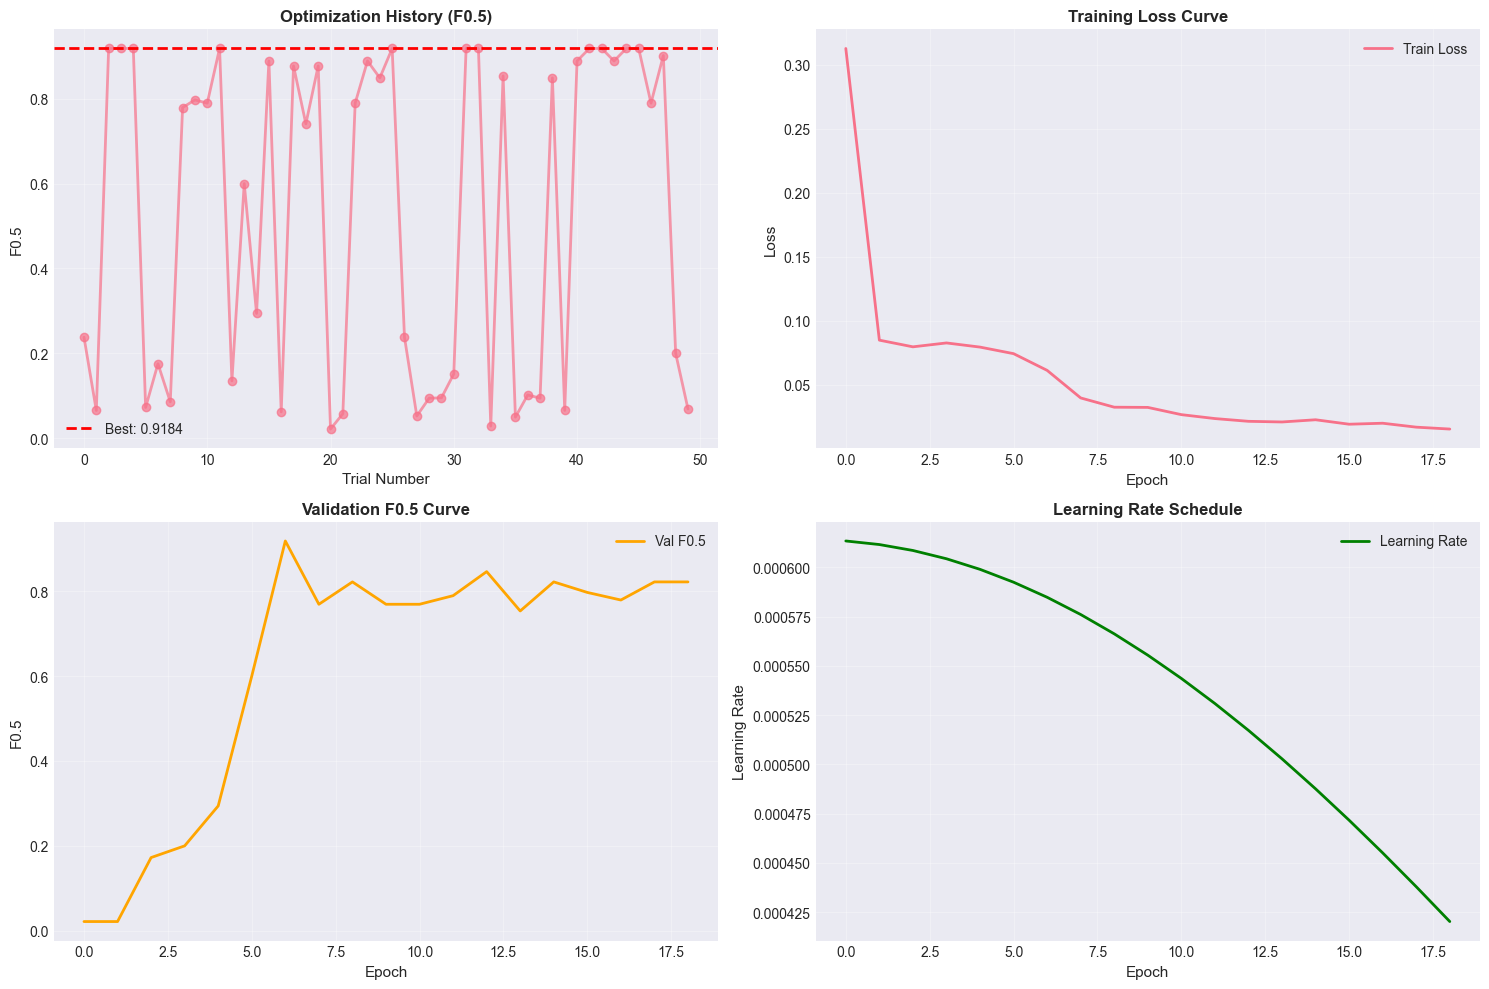

2026-04-06 03:06:47,901 - INFO - Визуализация истории оптимизации завершена


In [9]:
def train_epoch(model, train_loader, optimizer, criterion, device, clip_grad=1.0):
    """Обучение на одной эпохе с mini-batches."""
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()

        if clip_grad > 0:
            nn.utils.clip_grad_norm_(model.parameters(), clip_grad)

        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(train_loader.dataset)


def validate(model, val_loader, criterion, device):
    """Валидация модели."""
    model.eval()
    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item() * X_batch.size(0)

            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            labels = y_batch.cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(labels)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    pr_auc = average_precision_score(all_labels, all_probs)

    return total_loss / len(val_loader.dataset), pr_auc


logger.info("Начало расширенного подбора гиперпараметров с Optuna...")


def predict_on_loader(model, data_loader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(y_batch.cpu().numpy())

    return np.array(all_labels), np.array(all_probs)


def find_best_threshold(y_true, y_score, beta=0.5):
    thresholds = np.arange(0.0, 1.01, 0.01)
    fbeta_scores = []

    for thresh in thresholds:
        y_pred = (y_score >= thresh).astype(int)
        score = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        fbeta_scores.append(score)

    best_idx = int(np.argmax(fbeta_scores))
    best_threshold = thresholds[best_idx]
    best_score = fbeta_scores[best_idx]

    return best_threshold, best_score


def objective(trial):
    reset_seeds(42)

    hidden_dim = trial.suggest_int('hidden_dim', 32, 160, step=32)
    num_layers = trial.suggest_int('num_layers', 1, 4)
    bidirectional = True
    dropout = trial.suggest_float('dropout', 0.1, 0.6, step=0.1)

    learning_rate = trial.suggest_float('learning_rate', 1e-5, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-7, 1e-2, log=True)
    optimizer_type = trial.suggest_categorical('optimizer_type', ['adam', 'adamw', 'sgd'])

    criterion_type = trial.suggest_categorical('criterion_type', ['ce', 'weighted_ce', 'focal'])
    scheduler_type = trial.suggest_categorical('scheduler_type', ['none', 'step', 'cosine'])
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    clip_grad = trial.suggest_float('clip_grad', 0.5, 2.0, step=0.5)

    num_epochs = 100

    model_optuna = GRUClassifier(
        input_dim=n_features,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=2,
        dropout=dropout,
        bidirectional=bidirectional
    ).to(device)

    if criterion_type == 'ce':
        criterion = nn.CrossEntropyLoss()

    elif criterion_type == 'weighted_ce':
        fraud_weight = trial.suggest_float('fraud_weight', 2.0, 25.0)
        class_weights = torch.tensor([1.0, fraud_weight], dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    else:
        alpha_fraud = trial.suggest_float('alpha_fraud', 2.0, 25.0)
        gamma = trial.suggest_float('gamma', 1.0, 5.0)
        alpha = torch.tensor([1.0, alpha_fraud], dtype=torch.float32).to(device)
        criterion = FocalLoss(alpha=alpha, gamma=gamma)

    if optimizer_type == 'adam':
        optimizer = optim.Adam(
            model_optuna.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    elif optimizer_type == 'adamw':
        optimizer = optim.AdamW(
            model_optuna.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )
    else:
        momentum = trial.suggest_float('momentum', 0.8, 0.99)
        optimizer = optim.SGD(
            model_optuna.parameters(),
            lr=learning_rate,
            momentum=momentum,
            weight_decay=weight_decay
        )

    if scheduler_type == 'step':
        scheduler = optim.lr_scheduler.StepLR(
            optimizer,
            step_size=10,
            gamma=0.5
        )
    elif scheduler_type == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=50,
            eta_min=1e-6
        )
    else:
        scheduler = None

    train_loader = DataLoader(
        TensorDataset(X_train_tensor, y_train_tensor),
        batch_size=batch_size,
        shuffle=True
    )
    val_loader = DataLoader(
        TensorDataset(X_val_tensor, y_val_tensor),
        batch_size=batch_size,
        shuffle=False
    )

    patience = 10
    best_val_f05 = 0.0
    patience_counter = 0

    for epoch in range(num_epochs):
        train_loss = train_epoch(
            model_optuna,
            train_loader,
            optimizer,
            criterion,
            device,
            clip_grad=clip_grad
        )
        val_loss, val_pr_auc = validate(model_optuna, val_loader, criterion, device)

        y_val_true, y_val_score = predict_on_loader(model_optuna, val_loader, device)
        best_threshold_epoch, val_f05_epoch = find_best_threshold(
            y_val_true,
            y_val_score,
            beta=0.5
        )

        if scheduler is not None:
            scheduler.step()

        trial.report(val_f05_epoch, step=epoch)

        if trial.should_prune():
            raise optuna.TrialPruned()

        if val_f05_epoch > best_val_f05:
            best_val_f05 = val_f05_epoch
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    return best_val_f05


# ===== Create Study and Optimize =====
sampler = TPESampler(seed=42)
pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=10)

study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    study_name='gru_fraud_detection_tuning'
)

n_trials = 50
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
# ===== Best Trial =====
best_trial = study.best_trial
best_params = best_trial.params
clip_grad = best_params.get('clip_grad', 1.0)

logger.info(f"\n{'=' * 80}")
logger.info(f"Подбор гиперпараметров завершен за {len(study.trials)} trials")
logger.info(f"Лучший F0.5 на валидации: {best_trial.value:.4f}")
logger.info(f"\nОптимальные гиперпараметры:")
for key, value in sorted(best_params.items()):
    if isinstance(value, float):
        logger.info(f"  {key:<20} = {value:.6f}")
    else:
        logger.info(f"  {key:<20} = {value}")
logger.info(f"{'=' * 80}")


# ===== Train Best Model =====
reset_seeds(42)
logger.info("\nОбучение лучшей модели на train с контролем по val...")

model = GRUClassifier(
    input_dim=n_features,
    hidden_dim=best_params['hidden_dim'],
    num_layers=best_params['num_layers'],
    num_classes=2,
    dropout=best_params['dropout'],
    bidirectional=True
).to(device)

# ===== Setup Loss =====
criterion_type = best_params['criterion_type']

if criterion_type == 'ce':
    criterion = nn.CrossEntropyLoss()

elif criterion_type == 'weighted_ce':
    class_weights = torch.tensor(
        [1.0, best_params['fraud_weight']],
        dtype=torch.float32
    ).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

else:
    alpha = torch.tensor(
        [1.0, best_params['alpha_fraud']],
        dtype=torch.float32
    ).to(device)
    criterion = FocalLoss(alpha=alpha, gamma=best_params['gamma'])

# ===== Setup Optimizer =====
if best_params['optimizer_type'] == 'adam':
    optimizer = optim.Adam(
        model.parameters(),
        lr=best_params['learning_rate'],
        weight_decay=best_params['weight_decay']
    )

elif best_params['optimizer_type'] == 'adamw':
    optimizer = optim.AdamW(
        model.parameters(),
        lr=best_params['learning_rate'],
        weight_decay=best_params['weight_decay']
    )

else:
    optimizer = optim.SGD(
        model.parameters(),
        lr=best_params['learning_rate'],
        momentum=best_params['momentum'],
        weight_decay=best_params['weight_decay']
    )

# ===== Setup Scheduler =====
if best_params['scheduler_type'] == 'step':
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=10,
        gamma=0.5
    )
elif best_params['scheduler_type'] == 'cosine':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=50,
        eta_min=1e-6
    )
else:
    scheduler = None

# ===== Create DataLoaders =====
train_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=best_params['batch_size'],
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor, y_val_tensor),
    batch_size=best_params['batch_size'],
    shuffle=False
)

# ===== Training Loop =====
num_epochs = 100
best_val_f05 = 0.0
best_threshold_on_val = 0.5
patience_counter = 0
best_state_dict = None
patience = 12

train_losses = []
val_losses = []
val_pr_aucs = []
val_f05_scores = []
learning_rates = []

for epoch in range(num_epochs):
    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device,
        clip_grad=clip_grad
    )    
    val_loss, val_pr_auc = validate(model, val_loader, criterion, device)

    y_val_true_epoch, y_val_score_epoch = predict_on_loader(model, val_loader, device)
    val_threshold_epoch, val_f05_epoch = find_best_threshold(
        y_val_true_epoch,
        y_val_score_epoch,
        beta=0.5
    )

    if scheduler is not None:
        scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_pr_aucs.append(val_pr_auc)
    val_f05_scores.append(val_f05_epoch)
    learning_rates.append(optimizer.param_groups[0]['lr'])

    if (epoch + 1) % 10 == 0:
        lr = optimizer.param_groups[0]['lr']
        logger.info(
            f"Эпоха {epoch + 1:3d}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"val_pr_auc={val_pr_auc:.4f}, "
            f"val_f0.5={val_f05_epoch:.4f}, "
            f"lr={lr:.6f}"
        )

    if val_f05_epoch > best_val_f05:
        best_val_f05 = val_f05_epoch
        best_threshold_on_val = val_threshold_epoch
        patience_counter = 0
        best_state_dict = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= patience:
            logger.info(f"Ранняя остановка на эпохе {epoch + 1}")
            break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    model.to(device)

logger.info(f"Обучение завершено. Лучший F0.5 валидации: {best_val_f05:.4f}")
logger.info(f"Лучший порог по валидации: {best_threshold_on_val:.2f}")


# ===== Visualization of Optimization =====
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

trials_df = study.trials_dataframe()

axes[0, 0].plot(
    trials_df['number'],
    trials_df['value'],
    'o-',
    linewidth=2,
    markersize=6,
    alpha=0.7
)
axes[0, 0].axhline(
    y=best_trial.value,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f'Best: {best_trial.value:.4f}'
)
axes[0, 0].set_xlabel('Trial Number', fontsize=11)
axes[0, 0].set_ylabel('F0.5', fontsize=11)
axes[0, 0].set_title('Optimization History (F0.5)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(train_losses, linewidth=2, label='Train Loss')
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Training Loss Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(val_f05_scores, linewidth=2, color='orange', label='Val F0.5')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('F0.5', fontsize=11)
axes[1, 0].set_title('Validation F0.5 Curve', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(learning_rates, linewidth=2, color='green', label='Learning Rate')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

logger.info("Визуализация истории оптимизации завершена")

## Часть 6: Инференс и оценка модели

Генерация предсказаний и расчет метрик качества с оптимальным порогом.

2026-04-06 03:06:48,859 - INFO - Предсказания получены для 749 клиентов
2026-04-06 03:06:48,860 - INFO - Статистика скоров - Min: 0.004293, Max: 0.481531, Mean: 0.011622
2026-04-06 03:06:48,860 - INFO - Оптимальный порог по validation: 0.23 (лучший F0.5: 0.9184)



          ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ BiLSTM (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)           

ТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:
--------------------------------------------------------------------------------
  Архитектура: hidden_dim=32, num_layers=4, bidirectional=True
  Оптимизатор: ADAMW (lr=0.000614)
  Scheduler: COSINE
  Batch size: 128
  Dropout: 0.2

СТАТИСТИКА НАБОРА ДАННЫХ:
--------------------------------------------------------------------------------
  Всего клиентов:                       749    (100.0%)
  Мошенники:                              9    (  1.2%)
  Честные:                              740    ( 98.8%)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:
--------------------------------------------------------------------------------
  Предсказано как мошенник:              8    (  1.1%)
  Предсказано как честный:             741    ( 98.9%)
  Оптимальный порог:                 0.2300

МАТРИЦА ОШИБОК:
--------------------------------------------------------------------------------
  Истинные н

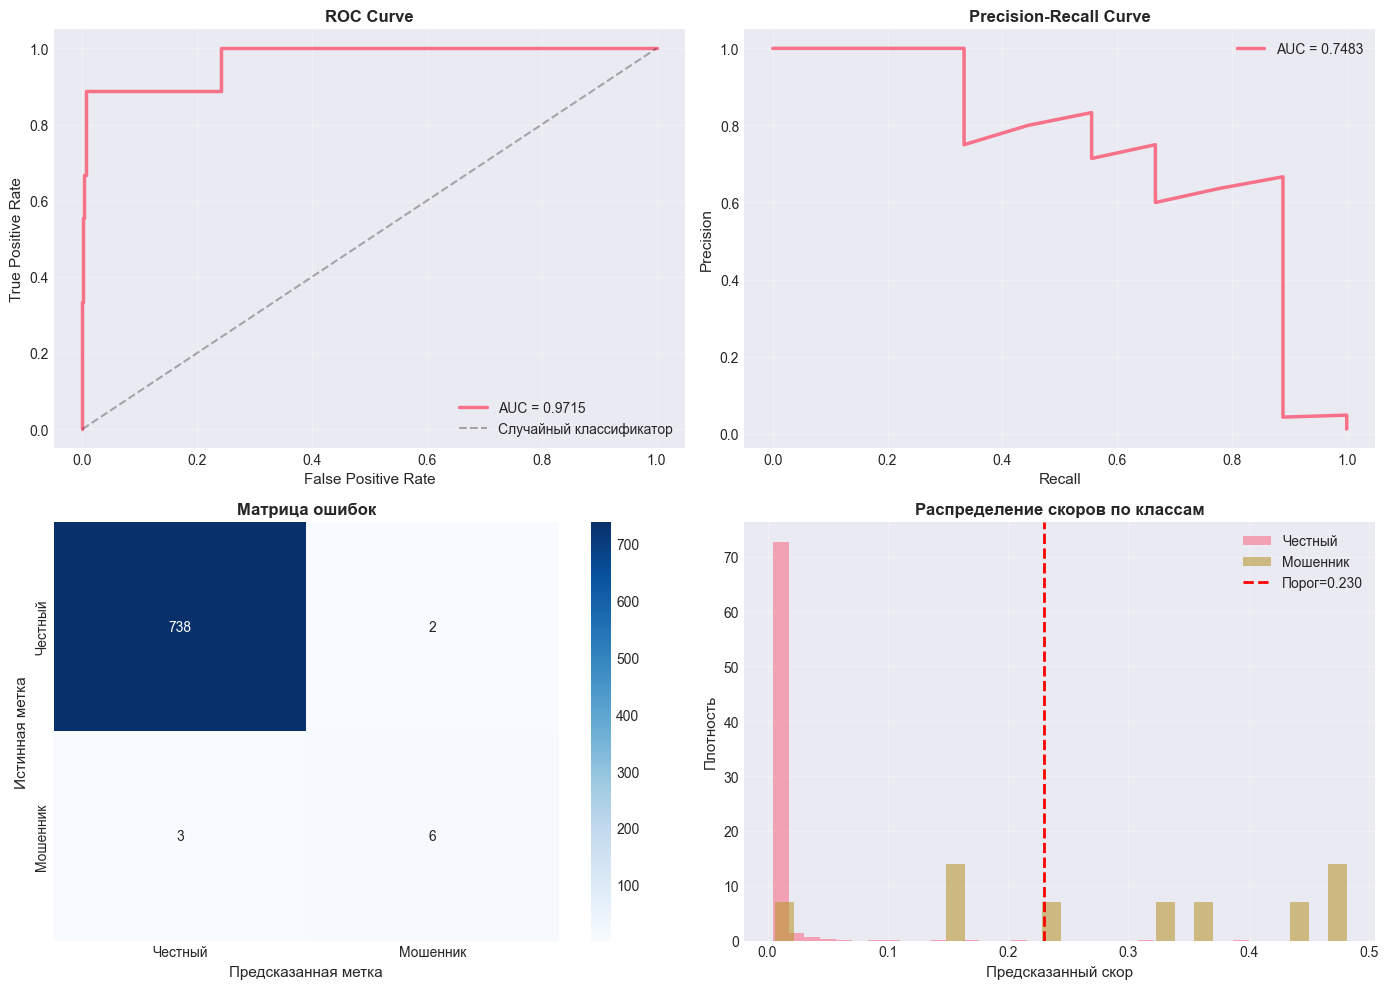

2026-04-06 03:06:49,114 - INFO - Оценка модели завершена успешно


In [10]:
# ===== INFERENCE ON FULL TEST SET =====

model.eval()
all_y_pred_proba = []
all_y_true = []

# Create test loader
test_loader = DataLoader(
    TensorDataset(X_test_tensor, y_test_tensor),
    batch_size=best_params['batch_size'],
    shuffle=False
)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_y_pred_proba.extend(probs)
        all_y_true.extend(y_batch.cpu().numpy())

y_pred_proba = np.array(all_y_pred_proba)
y_true = np.array(all_y_true)
y_score = y_pred_proba

logger.info(f"Предсказания получены для {len(y_pred_proba)} клиентов")
logger.info(f"Статистика скоров - Min: {y_score.min():.6f}, Max: {y_score.max():.6f}, Mean: {y_score.mean():.6f}")

# Find optimal threshold

optimal_thresh = best_threshold_on_val
y_pred = (y_score >= optimal_thresh).astype(int)

logger.info(f"Оптимальный порог по validation: {optimal_thresh:.2f} (лучший F0.5: {best_val_f05:.4f})")

# Calculate metrics
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

metrics = {
    'ROC-AUC': roc_auc_score(y_true, y_score),
    'PR-AUC': average_precision_score(y_true, y_score),
    'Accuracy': accuracy_score(y_true, y_pred),
    'Precision': precision_score(y_true, y_pred, zero_division=0),
    'Recall': recall_score(y_true, y_pred, zero_division=0),
    'F1': f1_score(y_true, y_pred, zero_division=0),
    'F0.5': fbeta_score(y_true, y_pred, beta=0.5, zero_division=0),
    'Specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
    'FPR': fp / (fp + tn) if (fp + tn) > 0 else 0.0,
    'FNR': fn / (fn + tp) if (fn + tp) > 0 else 0.0,
    'NPV': tn / (tn + fn) if (tn + fn) > 0 else 0.0,
}

# Print report
print("\n" + "=" * 80)
print("ОТЧЕТ ОБ ОЦЕНКЕ МОДЕЛИ BiLSTM (РАСШИРЕННЫЙ ПОДБОР - OPTUNA)".center(80))
print("=" * 80)

print("\nТЕМПЛАТА ОПТИМАЛЬНОЙ КОНФИГУРАЦИИ:")
print("-" * 80)
print(f"  Архитектура: hidden_dim={best_params['hidden_dim']}, num_layers={best_params['num_layers']}, bidirectional=True")
print(f"  Оптимизатор: {best_params['optimizer_type'].upper()} (lr={best_params['learning_rate']:.6f})")
print(f"  Scheduler: {best_params['scheduler_type'].upper()}")
print(f"  Batch size: {best_params['batch_size']}")
print(f"  Dropout: {best_params['dropout']}")

print("\nСТАТИСТИКА НАБОРА ДАННЫХ:")
print("-" * 80)
n_total = len(y_true)
n_fraud = (y_true == 1).sum()
n_nonfraud = (y_true == 0).sum()
print(f"  Всего клиентов:                {n_total:>10,}    ({100.0:>5.1f}%)")
print(f"  Мошенники:                     {n_fraud:>10,}    ({100*n_fraud/n_total:>5.1f}%)")
print(f"  Честные:                       {n_nonfraud:>10,}    ({100*n_nonfraud/n_total:>5.1f}%)")

print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАНИЙ:")
print("-" * 80)
n_pred_fraud = (y_pred == 1).sum()
n_pred_legit = (y_pred == 0).sum()
print(f"  Предсказано как мошенник:     {n_pred_fraud:>10,}    ({100*n_pred_fraud/n_total:>5.1f}%)")
print(f"  Предсказано как честный:      {n_pred_legit:>10,}    ({100*n_pred_legit/n_total:>5.1f}%)")
print(f"  Оптимальный порог:             {optimal_thresh:>10.4f}")

print("\nМАТРИЦА ОШИБОК:")
print("-" * 80)
print(f"  Истинные негативы (TN):        {tn:>10,}")
print(f"  Ложные позитивы (FP):          {fp:>10,}")
print(f"  Ложные негативы (FN):          {fn:>10,}")
print(f"  Истинные позитивы (TP):        {tp:>10,}")

print("\nМЕТРИКИ КАЧЕСТВА:")
print("-" * 80)
for metric_name, metric_value in sorted(metrics.items()):
    print(f"  {metric_name:<25} {metric_value:>10.4f}")

print("\nДЕТАЛЬНЫЙ ОТЧЕТ КЛАССИФИКАЦИИ:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=['Честный', 'Мошенник'], 
                          digits=4, zero_division=0))

# ===== Parity by Score Buckets =====

print("ПАРИТЕТ ПО БАКЕТАМ СКОРА (интервалы 0.1):")
print("-" * 80)
buckets = pd.cut(y_score, bins=10, labels=[f"{i*0.1:.1f}-{(i+1)*0.1:.1f}" for i in range(10)])
parity_df = pd.DataFrame({
    'bucket': buckets,
    'y_true': y_true,
    'y_score': y_score
})

parity_stats = parity_df.groupby('bucket', observed=True).agg({
    'y_true': ['count', 'sum', 'mean'],
    'y_score': ['min', 'max', 'mean']
}).round(4)

parity_stats.columns = ['count', 'fraud_count', 'fraud_rate', 'score_min', 'score_max', 'score_mean']
print(parity_stats.to_string())

# ===== Visualization =====

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
axes[0, 0].plot(fpr, tpr, linewidth=2.5, label=f'AUC = {metrics["ROC-AUC"]:.4f}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Случайный классификатор')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=11)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=11)
axes[0, 0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(alpha=0.3)

# PR Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_score)
axes[0, 1].plot(recall_vals, precision_vals, linewidth=2.5, label=f'AUC = {metrics["PR-AUC"]:.4f}')
axes[0, 1].set_xlabel('Recall', fontsize=11)
axes[0, 1].set_ylabel('Precision', fontsize=11)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='best')
axes[0, 1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
           xticklabels=['Честный', 'Мошенник'],
           yticklabels=['Честный', 'Мошенник'])
axes[1, 0].set_ylabel('Истинная метка', fontsize=11)
axes[1, 0].set_xlabel('Предсказанная метка', fontsize=11)
axes[1, 0].set_title('Матрица ошибок', fontsize=12, fontweight='bold')

# Score Distribution
axes[1, 1].hist(y_score[y_true == 0], bins=30, alpha=0.6, label='Честный', density=True)
axes[1, 1].hist(y_score[y_true == 1], bins=30, alpha=0.6, label='Мошенник', density=True)
axes[1, 1].axvline(optimal_thresh, color='red', linestyle='--', linewidth=2, label=f'Порог={optimal_thresh:.3f}')
axes[1, 1].set_xlabel('Предсказанный скор', fontsize=11)
axes[1, 1].set_ylabel('Плотность', fontsize=11)
axes[1, 1].set_title('Распределение скоров по классам', fontsize=12, fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 80)
logger.info("Оценка модели завершена успешно")